In [9]:
import pandas as pd
import yfinance as yf

TICKER = "AAPL"
START_DATE = "2025-01-01"
END_DATE = pd.Timestamp.today().normalize().strftime("%Y-%m-%d")

## Momentum Trend Detection

This notebook downloads adjusted daily prices for `AAPL` and computes two related signals:

- Daily dollar change: $P_t - P_{t-1}$
- Daily return: $\frac{P_t}{P_{t-1}} - 1$

The dollar change is useful for inspection. The return series is the more standard momentum input.

In [10]:
prices = yf.download(
    TICKER,
    start=START_DATE,
    end=END_DATE,
    auto_adjust=True,
    progress=False,
)

if prices.empty:
    raise ValueError(f"No price data returned for {TICKER} between {START_DATE} and {END_DATE}")

close = prices["Close"].squeeze("columns").copy()
if not isinstance(close, pd.Series):
    raise ValueError(f"Expected a single close-price series for {TICKER}, got shape {close.shape}")

daily_change = close.diff().dropna()
daily_return = close.pct_change().dropna()
momentum_20d = close.pct_change(periods=20).dropna()

summary = pd.concat(
    [
        close.rename("close"),
        close.diff().rename("daily_change"),
        close.pct_change().rename("daily_return"),
        close.pct_change(periods=20).rename("momentum_20d"),
    ],
    axis=1,
)

print("Close prices")
print(close.head())
print()
print("Daily dollar change")
print(daily_change.head())
print()
print("Daily return")
print(daily_return.head())
print()
print("Combined summary")
summary.tail()

Close prices
Date
2025-01-02    242.525162
2025-01-03    242.037827
2025-01-06    243.668915
2025-01-07    240.894073
2025-01-08    241.381409
Name: AAPL, dtype: float64

Daily dollar change
Date
2025-01-03   -0.487335
2025-01-06    1.631088
2025-01-07   -2.774841
2025-01-08    0.487335
2025-01-10   -5.818192
Name: AAPL, dtype: float64

Daily return
Date
2025-01-03   -0.002009
2025-01-06    0.006739
2025-01-07   -0.011388
2025-01-08    0.002023
2025-01-10   -0.024104
Name: AAPL, dtype: float64

Combined summary


,close,daily_change,daily_return,momentum_20d
Date,,,,
2026-04-10,260.480011,-0.009979,-0.000038,0.018455
2026-04-13,259.200012,-1.279999,-0.004914,0.036303
2026-04-14,258.829987,-0.370026,-0.001428,0.023772
2026-04-15,266.429993,7.600006,0.029363,0.047988
2026-04-16,263.399994,-3.029999,-0.011373,0.053853


In [13]:
# Quick shape overview of the notebook data
print(f"{TICKER} raw prices shape: {prices.shape} (rows, columns)")
print(f"Summary table shape: {summary.shape} (rows, columns)")
print()

print("Series lengths:")
print(f"- close: {close.shape[0]}")
print(f"- daily_change: {daily_change.shape[0]}")
print(f"- daily_return: {daily_return.shape[0]}")
print(f"- momentum_20d: {momentum_20d.shape[0]}")
print()

print("Date coverage:")
print(f"- prices: {prices.index.min().date()} -> {prices.index.max().date()}")
print(f"- summary: {summary.index.min().date()} -> {summary.index.max().date()}")
print()

print("Missing values in summary:")
print(summary.isna().sum())

AAPL raw prices shape: (322, 5) (rows, columns)
Summary table shape: (322, 4) (rows, columns)

Series lengths:
- close: 322
- daily_change: 321
- daily_return: 321
- momentum_20d: 302

Date coverage:
- prices: 2025-01-02 -> 2026-04-16
- summary: 2025-01-02 -> 2026-04-16

Missing values in summary:
close            0
daily_change     1
daily_return     1
momentum_20d    20
dtype: int64


Interpretation:

- `daily_change` measures absolute price movement in dollars.
- `daily_return` measures one-day normalized movement.
- `momentum_20d` is a simple medium-horizon momentum signal.

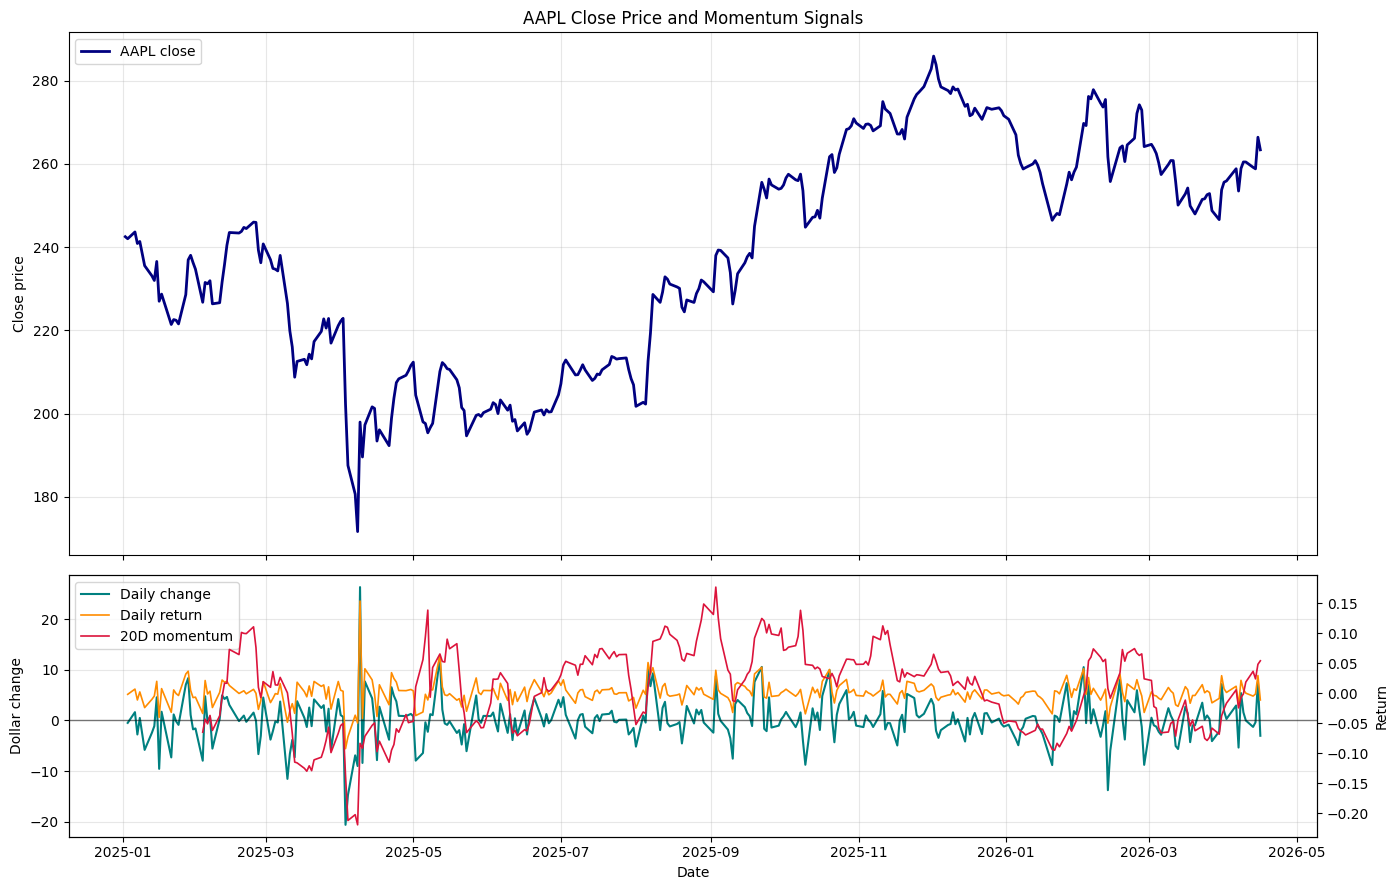

In [12]:
import matplotlib.pyplot as plt

fig, (ax_close, ax_signal) = plt.subplots(
    2,
    1,
    figsize=(14, 9),
    sharex=True,
    gridspec_kw={"height_ratios": [2, 1]},
)

ax_close.plot(close.index, close, color="navy", linewidth=2, label=f"{TICKER} close")
ax_close.set_title(f"{TICKER} Close Price and Momentum Signals")
ax_close.set_ylabel("Close price")
ax_close.grid(alpha=0.3)
ax_close.legend(loc="upper left")

ax_signal.plot(daily_change.index, daily_change, color="teal", linewidth=1.5, label="Daily change")
ax_signal.axhline(0, color="black", linewidth=1, alpha=0.5)
ax_signal.set_ylabel("Dollar change")
ax_signal.grid(alpha=0.3)

ax_signal_pct = ax_signal.twinx()
ax_signal_pct.plot(daily_return.index, daily_return, color="darkorange", linewidth=1.2, label="Daily return")
ax_signal_pct.plot(momentum_20d.index, momentum_20d, color="crimson", linewidth=1.2, label="20D momentum")
ax_signal_pct.set_ylabel("Return")

lines_left, labels_left = ax_signal.get_legend_handles_labels()
lines_right, labels_right = ax_signal_pct.get_legend_handles_labels()
ax_signal.legend(lines_left + lines_right, labels_left + labels_right, loc="upper left")
ax_signal.set_xlabel("Date")

fig.tight_layout()
plt.show()